In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from abstract_values.behavior.data import (
    FMRISubject,
    get_all_fmri_subjects,
    get_all_fmri_subject_ids,
    get_all_fmri_behavioral_data,
)

In [2]:
df = get_all_fmri_behavioral_data()
df = df[df['event_type'] == 'feedback']

df['response'] = df['response'].astype(float)

In [3]:
df.groupby(['subject', 'mapping']).size()

subject  mapping    
1        inverse_cdf    184
dtype: int64

In [15]:
# Count non-responses per subject (normalized)
non_responses = df[df['response'].isna()].groupby('subject').size() / df.groupby('subject').size()
print("Non-responses per subject:")
print(non_responses)

Non-responses per subject:
subject
1    0.086957
dtype: float64


In [4]:
rows = []
for subject_id in get_all_fmri_subject_ids():
    s = FMRISubject(subject_id)
    try:
        d = s.get_behavioral_data().reset_index()
        d = d[d['event_type'] == 'feedback'].copy()
        d['response'] = pd.to_numeric(d['response'], errors='coerce')
        rows.append({
            'subject': subject_id,
            'n_rows': len(d),
            'n_response_nan': d['response'].isna().sum(),
            'mappings': sorted(d['mapping'].dropna().unique().tolist()),
            'runs_found': sorted(d['run'].dropna().unique().tolist()),
        })
    except Exception as e:
        rows.append({'subject': subject_id, 'error': str(e)})

pd.DataFrame(rows)

,subject,n_rows,n_response_nan,mappings,runs_found
0,1,184,16,[inverse_cdf],"[1, 2, 3, 4, 5, 6, 7, 8]"


Text(0.5, 1.0, 'Subject 1: mean response by orientation')

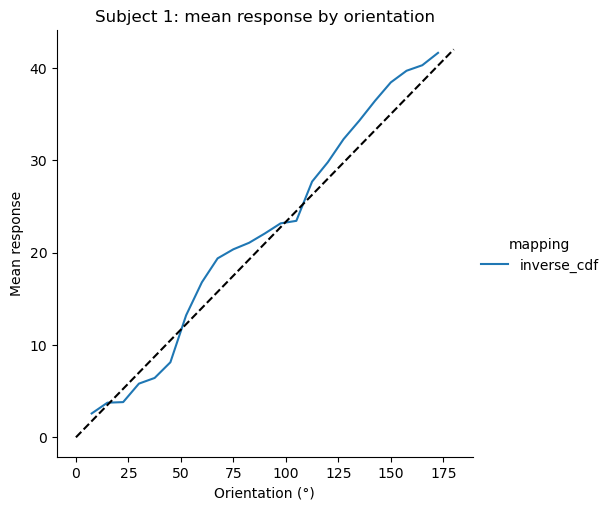

In [5]:
subject_id = 1
tmp = df.xs(subject_id, level='subject', drop_level=False).groupby(['subject', 'mapping', 'orientation'])['response'].mean()

g = sns.relplot(data=tmp.reset_index(), x='orientation', y='response', hue='mapping', kind='line')
plt.plot([0, 180], [0, 42], 'k--')
g.set_axis_labels('Orientation (°)', 'Mean response')
plt.title(f'Subject {subject_id}: mean response by orientation')

Text(0.5, 1.0, 'All subjects: mean response by orientation')

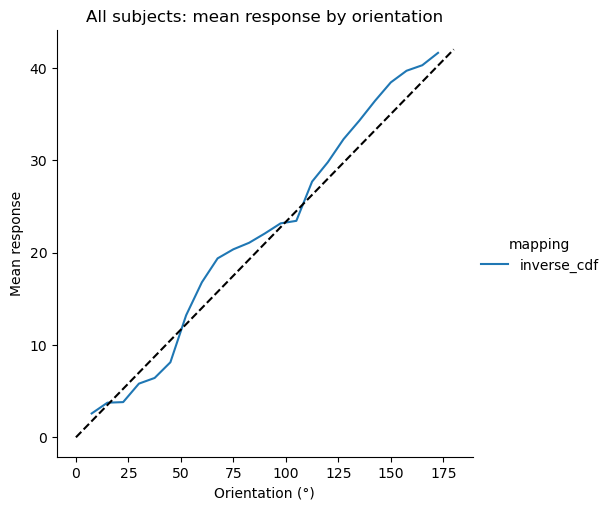

In [6]:
tmp = df.groupby(['subject', 'mapping', 'orientation'])['response'].mean()

g = sns.relplot(data=tmp.reset_index(), x='orientation', y='response', hue='mapping', kind='line')
plt.plot([0, 180], [0, 42], 'k--')
g.set_axis_labels('Orientation (°)', 'Mean response')
plt.title('All subjects: mean response by orientation')

Text(0.5, 1.0, 'All subjects: mean response by true value')

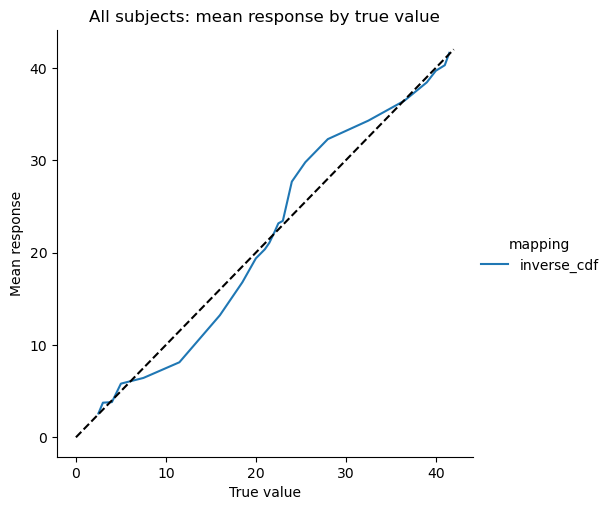

In [7]:
tmp = df.groupby(['subject', 'mapping', 'value'])['response'].mean()

g = sns.relplot(data=tmp.reset_index(), x='value', y='response', hue='mapping', kind='line')
plt.plot([0, 42], [0, 42], 'k--')
g.set_axis_labels('True value', 'Mean response')
plt.title('All subjects: mean response by true value')

Text(0.5, 1.0, 'Mean error by orientation (all subjects)')

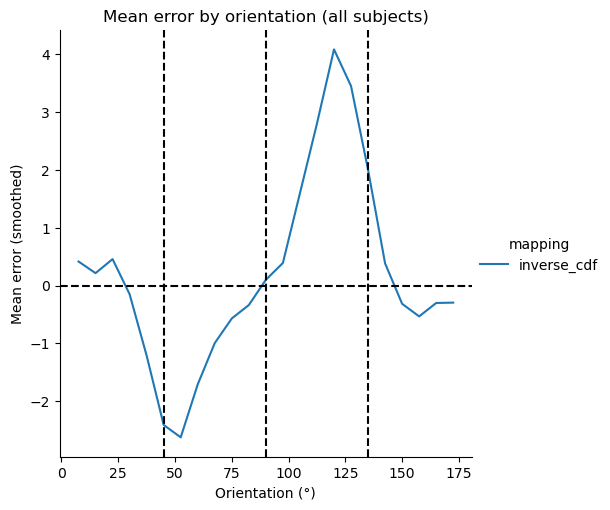

In [8]:
work = df.reset_index().copy()
work['error'] = work['response'] - work['value']

tmp = (
    work.groupby(['subject', 'mapping', 'orientation'], as_index=False)['error']
        .mean()
        .sort_values(['subject', 'mapping', 'orientation'])
)

tmp['error_smooth'] = (
    tmp.groupby(['subject', 'mapping'])['error']
       .transform(lambda s: s.rolling(3, center=True, min_periods=1).mean())
)

g = sns.relplot(data=tmp, x='orientation', y='error_smooth', hue='mapping', kind='line', errorbar='se')
g.set_axis_labels('Orientation (°)', 'Mean error (smoothed)')
plt.axhline(0, color='k', linestyle='--')
for ori in [45, 90, 135]:
    plt.axvline(ori, color='k', linestyle='--')
plt.title('Mean error by orientation (all subjects)')

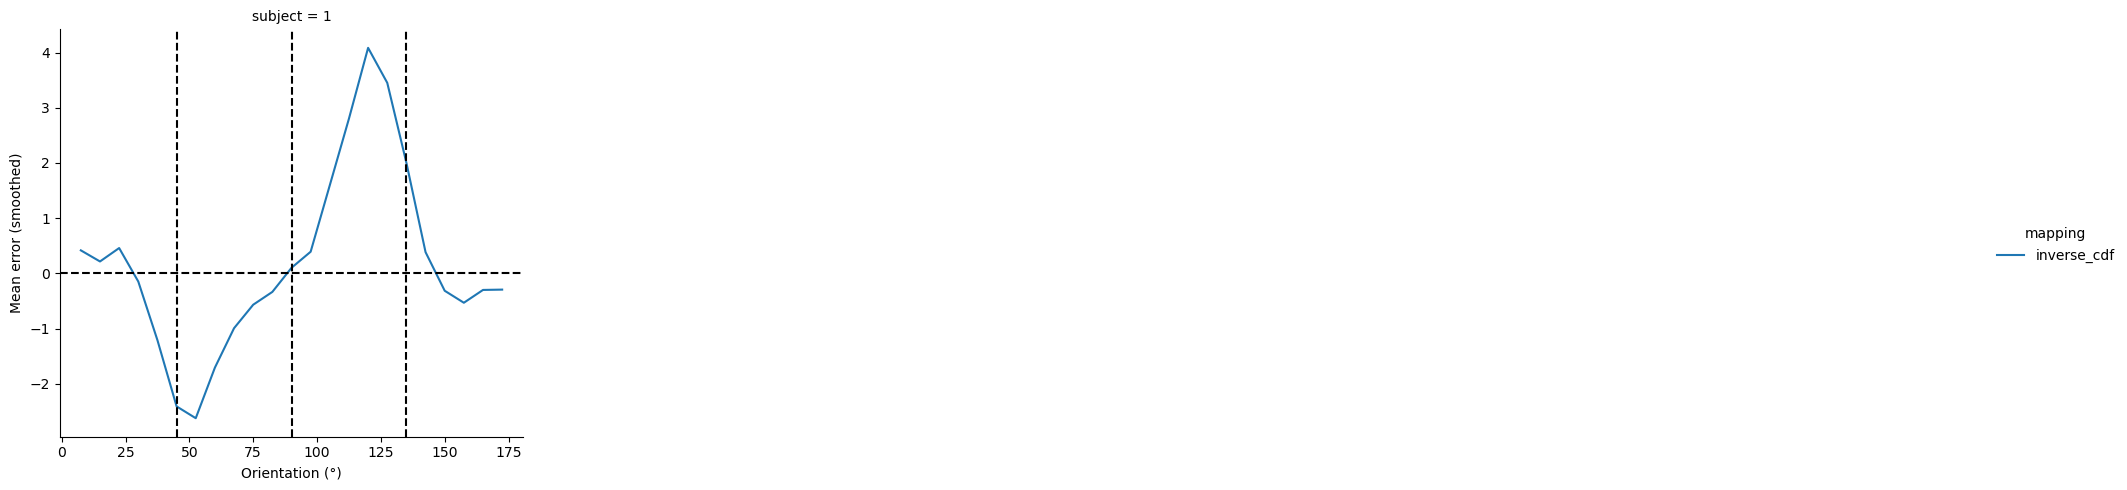

In [9]:
g = sns.relplot(data=tmp, x='orientation', y='error_smooth', hue='mapping', kind='line', errorbar='se',
                col='subject', col_wrap=4)
g.map(plt.axhline, y=0, color='k', linestyle='--')
for ori in [45, 90, 135]:
    g.map(plt.axvline, x=ori, color='k', linestyle='--')
g.set_axis_labels('Orientation (°)', 'Mean error (smoothed)')

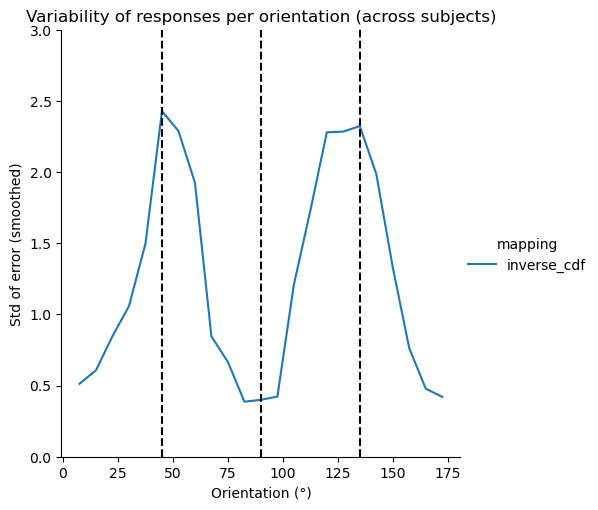

In [10]:
# Standard deviation of error per subject/mapping/orientation, smoothed over orientations
std_tmp = (
    work.groupby(['subject', 'mapping', 'orientation'], as_index=False)['error']
        .std()
        .rename(columns={'error': 'error_std'})
        .sort_values(['subject', 'mapping', 'orientation'])
)

std_tmp['error_std_smooth'] = (
    std_tmp.groupby(['subject', 'mapping'])['error_std']
           .transform(lambda s: s.rolling(3, center=True, min_periods=1).mean())
)

g = sns.relplot(data=std_tmp, x='orientation', y='error_std_smooth',
                hue='mapping', kind='line', errorbar='se')
g.set_axis_labels('Orientation (°)', 'Std of error (smoothed)')
plt.title('Variability of responses per orientation (across subjects)')

for ori in [45, 90, 135]:
    plt.axvline(ori, color='k', linestyle='--')

g.set(ylim=(0, 3))

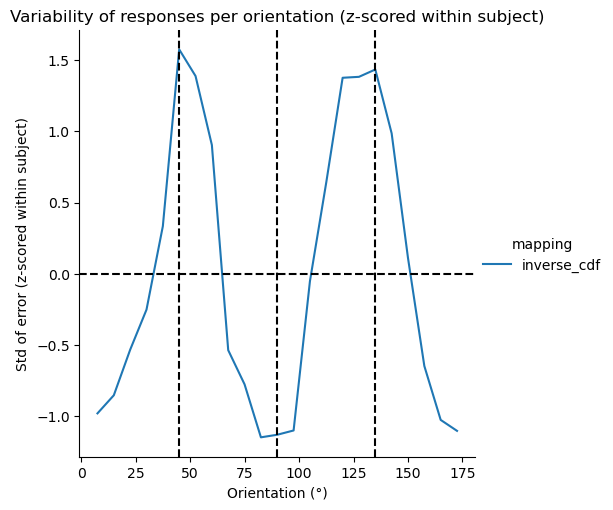

In [11]:
# Z-score error_std_smooth within each subject
std_tmp['error_std_z'] = (
    std_tmp.groupby('subject')['error_std_smooth']
           .transform(lambda s: (s - s.mean()) / s.std())
)

g = sns.relplot(data=std_tmp, x='orientation', y='error_std_z',
                hue='mapping', kind='line', errorbar='se')
g.set_axis_labels('Orientation (°)', 'Std of error (z-scored within subject)')
plt.title('Variability of responses per orientation (z-scored within subject)')
plt.axhline(0, color='k', linestyle='--')
for ori in [45, 90, 135]:
    plt.axvline(ori, color='k', linestyle='--')

Text(0.5, 1.0, 'Response time by run')

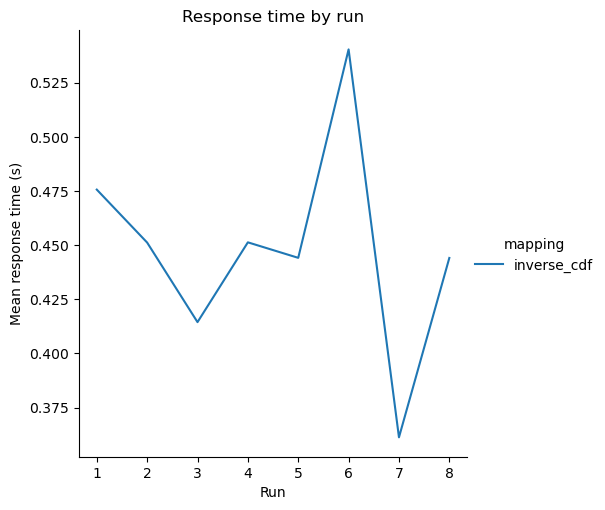

In [12]:
# Response time across runs (check for fatigue / learning effects)
work['response_time'] = pd.to_numeric(work['response_time'], errors='coerce')
rt_tmp = work.groupby(['subject', 'mapping', 'run'], as_index=False)['response_time'].mean()

g = sns.relplot(data=rt_tmp, x='run', y='response_time', hue='mapping', kind='line', errorbar='se')
g.set_axis_labels('Run', 'Mean response time (s)')
plt.title('Response time by run')

,mean,std
mapping,,
inverse_cdf,1.446429,NaN


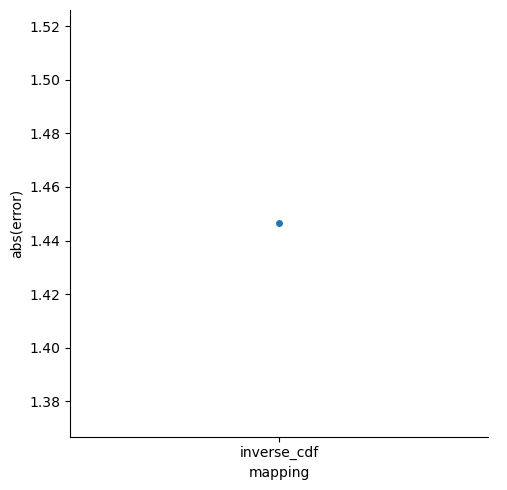

In [16]:
df['error'] = df['response'] - df['value']
df['abs(error)'] = df['error'].abs()
tmp = df.groupby(['subject', 'mapping'])['abs(error)'].mean()

sns.catplot(data=tmp.to_frame("abs(error)"), x='mapping', y='abs(error)', kind='swarm')

tmp.groupby('mapping').agg(['mean', 'std'])

In [ ]:
df['resp']

onset event_type  phase  \
subject session mapping     run trial_nr                                 
1       1       inverse_cdf 1   1          53.248524   feedback      5   
                                2          65.774292   feedback      5   
                                3          78.669620   feedback      5   
                                4          91.800405   feedback      5   
                                5         104.793626   feedback      5   
...                                              ...        ...    ...   
                            8   180       289.701362   feedback      5   
                                181       301.458584   feedback      5   
                                182       314.171955   feedback      5   
                                183       328.116412   feedback      5   
                                184       341.261929   feedback      5   

                                          response  nr_frames  orientation  \
subject session mapping     run trial_nr                                     
1       1       inverse_cdf 1   1             33.0       61.0        112.5   
                                2              NaN       60.0        120.0   
                                3             21.5       61.0         82.5   
                                4              NaN       60.0         15.0   
                                5              NaN       60.0          7.5   
...                                            ...        ...          ...   
                            8   180            7.0       61.0         37.5   
                                181           21.0       61.0         82.5   
                                182           16.5       61.0         60.0   
                                183           28.0       61.0        112.5   
                                184           38.5       61.0        150.0   

                                          value  reward  response_time  \
subject session mapping     run trial_nr                                 
1       1       inverse_cdf 1   1          24.0    65.5       0.033560   
                                2          25.5     0.0            NaN   
                                3          21.5    62.0       0.550717   
                                4           3.0     0.0            NaN   
                                5           2.5     0.0            NaN   
...                                         ...     ...            ...   
                            8   180         7.5    42.0       0.549041   
                                181        21.5    42.0       0.350488   
                                182        18.5    57.0       0.117024   
                                183        24.0    61.0       0.117916   
                                184        39.0    47.0       0.319171   

                                           onset_abs  duration  error  \
subject session mapping     run trial_nr                                
1       1       inverse_cdf 1   1         233.010744  1.015306    9.0   
                                2         245.536512  1.000920    NaN   
                                3         258.431840  1.017611    0.0   
                                4         271.562625  1.000110    NaN   
                                5         284.555846  1.000906    NaN   
...                                              ...       ...    ...   
                            8   180       294.928416  1.016501   -0.5   
                                181       306.685638  1.017563   -0.5   
                                182       319.399010  1.015979   -2.0   
                                183       333.343466  1.017563    4.0   
                                184       346.488983  1.017601   -0.5   

                                          abs(error)  
subject session mapping     run trial_nr              
1       1       inverse_cdf 1   1             